# Подготовка шаблона


In [ ]:
%load_ext autoreload
%autoreload 2

import io
import cv2
import json
import numpy as np

from PIL import Image
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt

from utils import (
    generate_template,
    overlay_character,
    template_meta,
    build_triangulation,
    draw_triangulation,
    markup_skeleton,
    save_skeleton,
    animate_character,
    render_svg,
)

# --- параметры шаблона ---
CANVAS_SIZE = (1240, 1754)   # A4 @ 150 DPI (h, w)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

TITLE = "Sketch Factory"
OUTPUT_DIR = "output"

CHAR_ID = "001"
CHAR_DIR = f"templates/{CHAR_ID}"

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
print(f"Canvas:      {CANVAS_SIZE[1]}x{CANVAS_SIZE[0]}")
print(f"Drawing bbox: {meta['drawing_bbox']}")
print(f"Markers:      {meta['marker_centers']}")

## Пустой А4

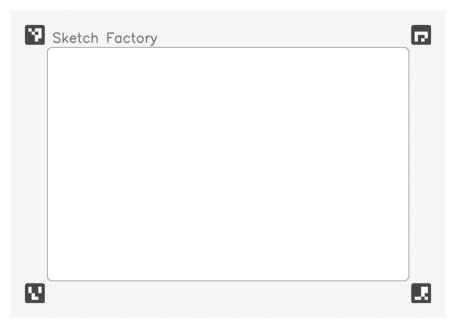

Сохранено: output\template.png


In [13]:
result = generate_template(
    output_path=f"{OUTPUT_DIR}/template.png",
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
    title=TITLE,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result["template"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Сохранено: {result['template_path']}")

## Наложение персонажа PNG

image_rect: [345, 244, 1064, 752]


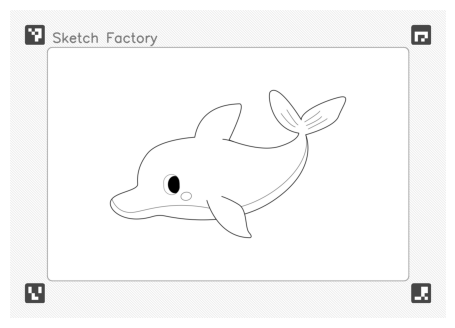

In [19]:
# SVG → шаблон для печати
result_char = overlay_character(
    template_path=f"{OUTPUT_DIR}/template.png",
    svg_path=f"{CHAR_DIR}/mask.svg",
    output_path=f"{CHAR_DIR}/template.png",
    content_scale=0.8,
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
)

print(f"image_rect: {result_char['image_rect']}")

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result_char["template"], cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

## Разметка скелета

In [20]:
# --- Если нужна новая разметка ---
# img = render_svg(f"{CHAR_DIR}/mask.svg")
# keypoints = markup_skeleton(img)
# save_skeleton(img, keypoints, output_dir=CHAR_DIR, char_id=CHAR_ID)

# --- Загрузка готового ---
with open(f"{CHAR_DIR}/skeleton.json", encoding="utf-8") as f:
    skel = json.load(f)
keypoints = skel["keypoints"]
print(f"Загружено {len(keypoints)} точек: {list(keypoints.keys())}")

Загружено 11 точек: ['nose', 'upper_fin1', 'upper_fin2', 'lower_fin1', 'lower_fin2', 'left_tail1', 'right_tail1', 'center_tail1', 'center_tail2', 'center_tail3', 'head']


Триангуляция

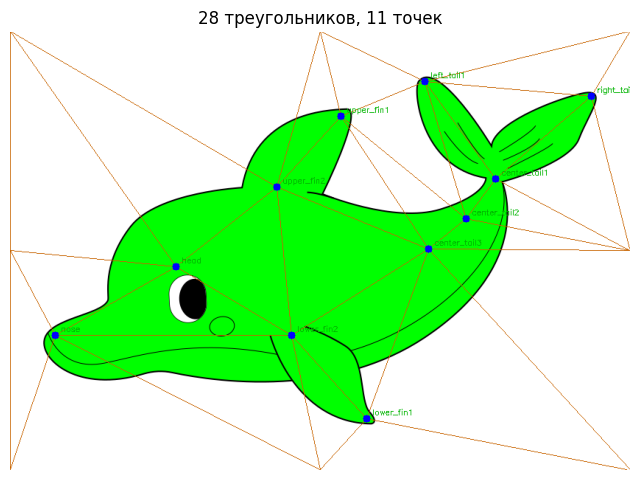

In [24]:
char_img = render_svg(f"{CHAR_DIR}/mask.svg")
th, tw = char_img.shape[:2]

ctrl_pts, tri, n_kp, names = build_triangulation(keypoints, tw, th)
vis = draw_triangulation(char_img, ctrl_pts, tri, n_kp, names)

plt.figure(figsize=(8, 6))
plt.imshow(vis)  # draw_triangulation уже возвращает RGBA
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} точек")
plt.show()

### Анимация

In [31]:
# --- motion config (подкрути под своего перса) ---
# - dx - амплитуда по горизонтали (пиксели). 12 = точка ходит ±12px влево-вправо
# - dy - амплитуда по вертикали. 20 = ±20px вверх-вниз
# - freq - скорость. 1.0 = один полный цикл за анимацию, 2.0 = два цикла (быстрее дёргается)
# - phase - сдвиг фазы (0..1). 0.0 = начинает сразу, 0.5 = начинает с противофазы. Нужно чтобы хвост волнообразно шёл - base с phase=0.6, mid=0.3, tip=0.0


FPS, DURATION = 15, 2

{
  "center_tail3": {"dx": 3,  "dy": 0,  "freq": 1.0, "phase": 0.0},
  "center_tail2": {"dx": 6,  "dy": 0,  "freq": 1.0, "phase": 0.15},
  "center_tail1": {"dx": 10, "dy": 0,  "freq": 1.0, "phase": 0.3},
  "left_tail1":   {"dx": 14, "dy": 8,  "freq": 1.0, "phase": 0.45},
  "right_tail1":  {"dx": 14, "dy": 8,  "freq": 1.0, "phase": 0.45},
  "upper_fin1":   {"dx": 6,  "dy": 0,  "freq": 1.5, "phase": 0.0},
  "upper_fin2":   {"dx": 4,  "dy": 0,  "freq": 1.5, "phase": 0.15},
  "lower_fin1":   {"dx": 6,  "dy": 0,  "freq": 1.5, "phase": 0.0},
  "lower_fin2":   {"dx": 4,  "dy": 0,  "freq": 1.5, "phase": 0.15},
  "head":         {"dx": 0,  "dy": 3,  "freq": 1.0, "phase": 0.5},
  "nose":         {"dx": 0,  "dy": 4,  "freq": 1.0, "phase": 0.55}
}


# with open(f"{CHAR_DIR}/motion.json") as f:
#     MOTION = json.load(f)
# MOTION

{'center_tail3': {'dx': 3, 'dy': 0, 'freq': 1.0, 'phase': 0.0},
 'center_tail2': {'dx': 6, 'dy': 0, 'freq': 1.0, 'phase': 0.15},
 'center_tail1': {'dx': 10, 'dy': 0, 'freq': 1.0, 'phase': 0.3},
 'left_tail1': {'dx': 14, 'dy': 8, 'freq': 1.0, 'phase': 0.45},
 'right_tail1': {'dx': 14, 'dy': 8, 'freq': 1.0, 'phase': 0.45},
 'upper_fin1': {'dx': 6, 'dy': 0, 'freq': 1.5, 'phase': 0.0},
 'upper_fin2': {'dx': 4, 'dy': 0, 'freq': 1.5, 'phase': 0.15},
 'lower_fin1': {'dx': 6, 'dy': 0, 'freq': 1.5, 'phase': 0.0},
 'lower_fin2': {'dx': 4, 'dy': 0, 'freq': 1.5, 'phase': 0.15},
 'head': {'dx': 0, 'dy': 3, 'freq': 1.0, 'phase': 0.5},
 'nose': {'dx': 0, 'dy': 4, 'freq': 1.0, 'phase': 0.55}}

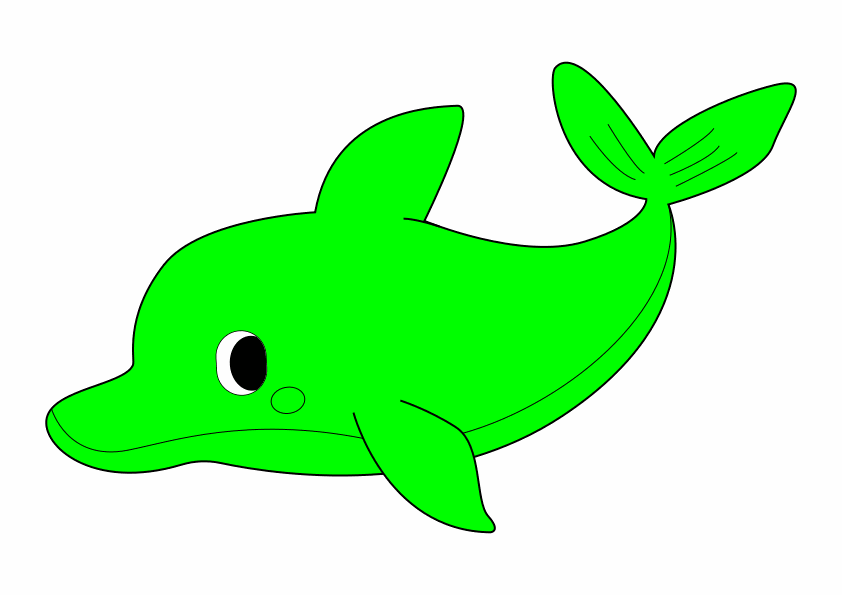

In [32]:
char_img = render_svg(f"{CHAR_DIR}/mask.svg")
char_img = cv2.cvtColor(char_img, cv2.COLOR_RGBA2BGRA)

frames = animate_character(char_img, keypoints, MOTION, fps=15, duration=2)

pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
buf = io.BytesIO()
pil_frames[0].save(buf, format="GIF", save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 15, loop=0, disposal=2)
display(IPImage(data=buf.getvalue(), width=500))

In [22]:
with open(f"{CHAR_DIR}/motion.json", "w") as f:
    json.dump(MOTION, f, indent=2)
print("Сохранено!")

Сохранено!


# RND